# Mental Health Detection via Knowledge-Infused Heterogeneous GNN
## Pipeline: Text → Entity Extraction → Graph → HGNN + Domain Adversarial → Explainability

**Datasets**: Dreaddit (Reddit) & Mental Health Counseling Conversations  
**Model**: Heterogeneous Graph Attention Network + Gradient Reversal Layer  
**Goal**: Cross-domain stress/non-stress classification with clinical explainability


## 1. Install and Import Required Libraries

In [13]:
import subprocess, sys
# Add project root to path
sys.path.insert(0, ".")

import warnings
warnings.filterwarnings("ignore")

import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk

# Download NLTK resources (punkt_tab required by NLTK >= 3.9)
for res in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    nltk.download(res, quiet=True)

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"MPS     : {torch.backends.mps.is_available()}")

DEVICE = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")


Python  : 3.9.6 (default, Jan  9 2026, 11:03:41) 
[Clang 17.0.0 (clang-1700.6.4.2)]
PyTorch : 2.8.0
CUDA    : False
MPS     : True
Using device: mps


In [14]:
from src.utils import load_config, set_seed, get_device, clean_text

CONFIG = load_config("config.yaml")
set_seed(CONFIG["training"]["seed"])
print("Config loaded ✓")
print(f"  Datasets: {[d['name'] for d in CONFIG['data']['datasets']]}")
print(f"  Epochs  : {CONFIG['training']['epochs']}")
print(f"  Hidden  : {CONFIG['model']['hidden_dim']}")


Config loaded ✓
  Datasets: ['dreaddit', 'counseling']
  Epochs  : 50
  Hidden  : 128


## 2. Load Datasets (Dreaddit & Mental Health Counseling)

In [15]:
from src.preprocessing import prepare_all_datasets

datasets = prepare_all_datasets(CONFIG)

for name, ds in datasets.items():
    df = ds.to_dataframe()
    print(f"\n── {name} ({len(ds)} samples) ──────────────────────")
    print(f"  Label distribution: {df['label'].value_counts().to_dict()}")
    print(f"  Sample text: {df['text'].iloc[0][:120]} …")


[Cache] Loading Dreaddit train from disk …
[Cache] Loading Dreaddit test from disk …
[Cache] Loading Counseling from disk …

── dreaddit_train (2838 samples) ──────────────────────
  Label distribution: {1: 1488, 0: 1350}
  Sample text: He said he had not felt that way before, suggeted I go rest and so ..TRIGGER AHEAD IF YOUI'RE A HYPOCONDRIAC LIKE ME: i  …

── dreaddit_test (715 samples) ──────────────────────
  Label distribution: {1: 369, 0: 346}
  Sample text: Its like that, if you want or not.“ ME: I have no problem, if it takes longer. But you asked my friend for help and let  …

── counseling (2000 samples) ──────────────────────
  Label distribution: {1: 2000}
  Sample text: I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worth …


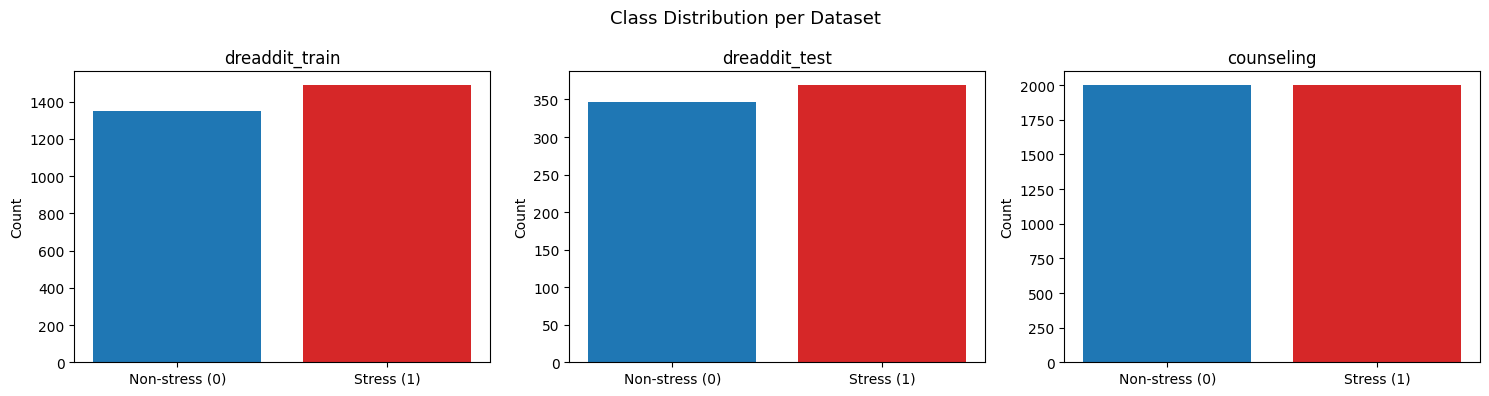

In [16]:
# Visualize class distribution
fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4))
if len(datasets) == 1:
    axes = [axes]
for ax, (name, ds) in zip(axes, datasets.items()):
    df = ds.to_dataframe()
    counts = df["label"].value_counts().sort_index()
    ax.bar(["Non-stress (0)", "Stress (1)"], counts.values, color=["tab:blue", "tab:red"])
    ax.set_title(name)
    ax.set_ylabel("Count")
plt.suptitle("Class Distribution per Dataset", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Text Preprocessing Pipeline

In [17]:
from src.utils import clean_text

sample_text = "I can't sleep 😔 and feel EXHAUSTED all the time. Visit https://example.com for help!"
print("Original :", sample_text)
print("Cleaned  :", clean_text(sample_text))

# Show a few preprocessed samples from Dreaddit
dreaddit_df = datasets["dreaddit_train"].to_dataframe()
dreaddit_df["clean_text"] = datasets["dreaddit_train"].clean_texts
dreaddit_df["tokens"] = datasets["dreaddit_train"].tokens
dreaddit_df[["text", "clean_text", "tokens", "label"]].head(3)


Original : I can't sleep 😔 and feel EXHAUSTED all the time. Visit https://example.com for help!
Cleaned  : i can t sleep and feel exhausted all the time visit for help


,text,clean_text,tokens,label
0,"He said he had not felt that way before, sugge...",he said he had not felt that way before sugget...,"[said, felt, way, suggeted, go, rest, trigger,...",1
1,"Hey there r/assistance, Not sure if this is th...",hey there r assistance not sure if this is the...,"[hey, assistance, sure, right, place, post, go...",0
2,My mom then hit me with the newspaper and it s...,my mom then hit me with the newspaper and it s...,"[mom, hit, newspaper, shocked, would, know, li...",1


## 4. Medical Entity Extraction and Concept Mapping

In [18]:
from src.entity_extraction import MedicalEntityExtractor, ALL_CONCEPTS, ALL_CATEGORIES

extractor = MedicalEntityExtractor()

test_texts = [
    "I can't sleep and feel exhausted all the time.",
    "I feel hopeless and worthless. I don't know why I even bother.",
    "The anxiety is overwhelming me and I keep panicking about everything.",
    "I've been so lonely lately, completely isolated from everyone.",
]

for text in test_texts:
    result = extractor.extract(text)
    print(f"\nText: {text}")
    for e in result.entities:
        print(f"  '{e.surface}' → [{e.concept}] ({e.category})")



Text: I can't sleep and feel exhausted all the time.
  'sleep' → [sleep_disturbance] (sleep_disorder)
  'exhausted' → [fatigue] (sleep_disorder)

Text: I feel hopeless and worthless. I don't know why I even bother.
  'hopeless' → [hopelessness] (mood_disorder)
  'worthless' → [worthlessness] (mood_disorder)

Text: The anxiety is overwhelming me and I keep panicking about everything.
  'anxiety' → [anxiety] (anxiety_disorder)
  'overwhelm' → [overwhelm] (anxiety_disorder)
  'panic' → [panic_attack] (anxiety_disorder)

Text: I've been so lonely lately, completely isolated from everyone.
  'lonely' → [loneliness] (social_disorder)
  'isolated' → [social_isolation] (social_disorder)


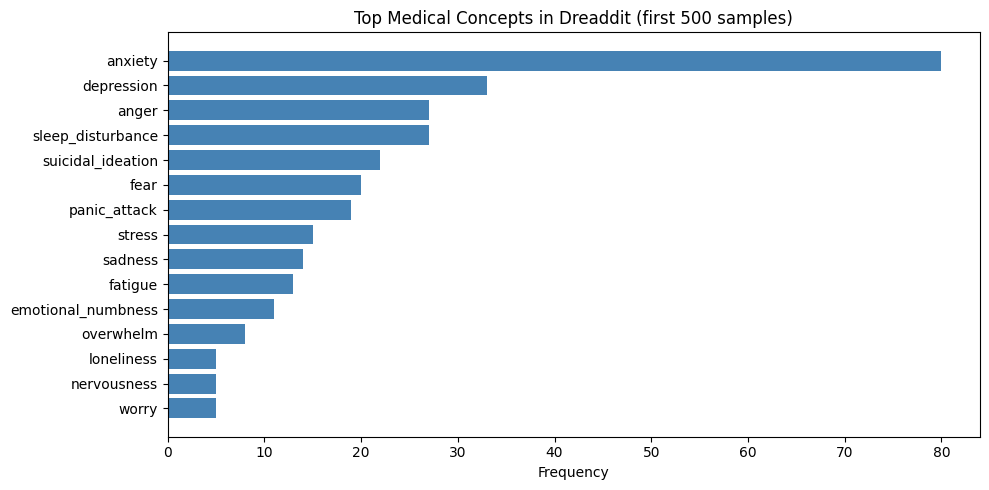

In [19]:
# Visualize entity frequency in Dreaddit
from collections import Counter

all_entities = []
for text in datasets["dreaddit_train"].clean_texts[:500]:
    r = extractor.extract(text)
    all_entities.extend([e.concept for e in r.entities])

entity_counts = Counter(all_entities).most_common(15)
labels_e, values_e = zip(*entity_counts) if entity_counts else ([], [])

plt.figure(figsize=(10, 5))
plt.barh(list(labels_e)[::-1], list(values_e)[::-1], color="steelblue")
plt.xlabel("Frequency")
plt.title("Top Medical Concepts in Dreaddit (first 500 samples)")
plt.tight_layout()
plt.show()


## 5. Heterogeneous Graph Construction

In [27]:
# Force reload all src modules to pick up any code changes without restarting kernel
import importlib, sys

mods_to_reload = [k for k in sys.modules if k.startswith("src.")]
for mod in mods_to_reload:
    try:
        importlib.reload(sys.modules[mod])
    except Exception:
        pass

print("Modules reloaded ✓")


Modules reloaded ✓


In [22]:
from src.graph import HeteroGraphBuilder, save_graph, load_graph

GRAPH_PATH = Path("data/graphs/hetero_graph.pkl")

if GRAPH_PATH.exists():
    print("Loading cached graph …")
    graph = load_graph(GRAPH_PATH)
else:
    builder = HeteroGraphBuilder(CONFIG)
    ds_list = [datasets["dreaddit_train"], datasets["counseling"]]
    graph = builder.build(ds_list)
    save_graph(graph, GRAPH_PATH)

print("\n" + graph.summary())


[Graph] Building vocabulary …
[Graph] Computing TF-IDF doc-word edges …


[Graph] Building word-word co-occurrence edges …


[Graph] Building word-concept edges …
[Graph] Building concept-category edges …
[Graph] Building concept-concept edges …
[Graph] Done!
Nodes → docs:4838  words:6089  concepts:27  categories:5
Edges → doc-word:112483  word-word:333415  word-concept:44  concept-cat:27  concept-concept:77
  Graph saved → data/graphs/hetero_graph.pkl

Nodes → docs:4838  words:6089  concepts:27  categories:5
Edges → doc-word:112483  word-word:333415  word-concept:44  concept-cat:27  concept-concept:77


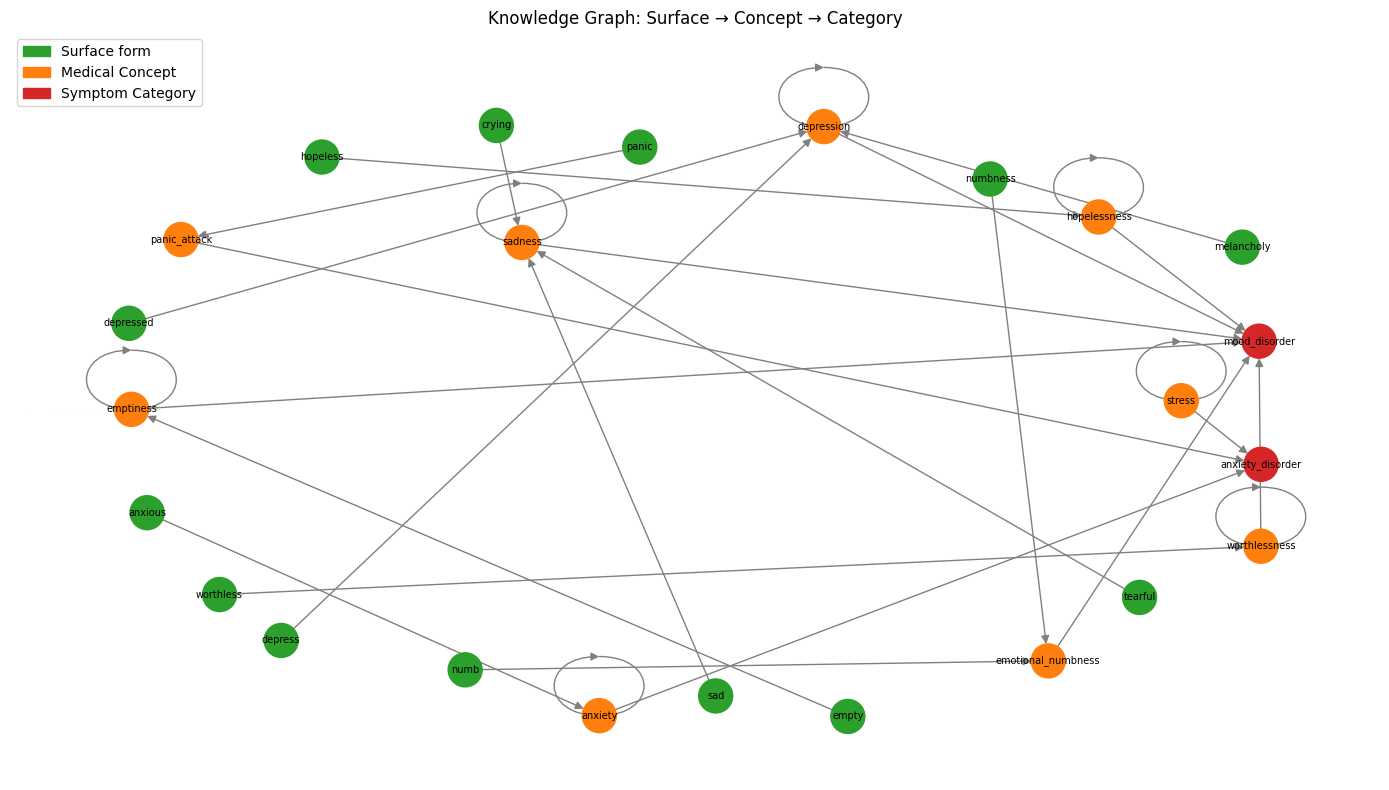

In [23]:
import networkx as nx

# Visualize a small subgraph (concept-category relationships)
G_small = nx.DiGraph()
from src.entity_extraction import LEXICON

for surface, (concept, category) in list(LEXICON.items())[:20]:
    G_small.add_edge(concept, category, relation="belongs_to")
    G_small.add_edge(surface, concept, relation="maps_to")

colors = []
for node in G_small.nodes:
    if node in ALL_CATEGORIES:
        colors.append("tab:red")
    elif node in ALL_CONCEPTS:
        colors.append("tab:orange")
    else:
        colors.append("tab:green")

pos = nx.spring_layout(G_small, seed=42, k=2)
plt.figure(figsize=(14, 8))
nx.draw_networkx(G_small, pos, node_color=colors, node_size=600,
                 font_size=7, arrows=True, arrowsize=12, edge_color="gray")
legend = [
    mpatches.Patch(color="tab:green", label="Surface form"),
    mpatches.Patch(color="tab:orange", label="Medical Concept"),
    mpatches.Patch(color="tab:red", label="Symptom Category"),
]
plt.legend(handles=legend, loc="upper left")
plt.title("Knowledge Graph: Surface → Concept → Category")
plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Node Embedding Generation

In [24]:
from src.graph import build_node_features

FEATURES_PATH = Path("data/graphs/node_features.pt")

if FEATURES_PATH.exists():
    print("Loading cached node features …")
    node_feats = torch.load(FEATURES_PATH, map_location="cpu")
else:
    ds_list = [datasets["dreaddit_train"], datasets["counseling"]]
    node_feats = build_node_features(graph, ds_list, CONFIG, device="cpu")
    torch.save(node_feats, FEATURES_PATH)

for ntype, feat in node_feats.items():
    print(f"  {ntype:20s}: shape={feat.shape}")


  [DocumentEmbedder] Loading allenai/scibert_scivocab_uncased …


  [WordEmbedder] GloVe not found – using random init.
  [ConceptEmbedder] Loading bert-base-uncased …
  document            : shape=torch.Size([4838, 768])
  word                : shape=torch.Size([6089, 100])
  medical_concept     : shape=torch.Size([27, 768])
  symptom_category    : shape=torch.Size([5, 768])


## 7. Build PyG Heterogeneous Graph & Model

### Architecture Overview:
```
Input node features (projected → hidden_dim=128)
↓
HGT Layer × 2  (num_heads=8, dropout=0.5)
↓
Document node embeddings
↓
Classifier head  →  Stress / Non-stress
↓ (during training)
Gradient Reversal Layer
↓
Domain classifier  →  Reddit / Counseling
```

In [25]:
from src.graph.graph_builder import HeteroGraphBuilder as GB
from src.models import MentalHealthGNN

# Convert to PyG
builder = GB(CONFIG)
pyg_data = builder.to_pyg(graph, device=DEVICE)

# Attach features + add reverse edges
for ntype, feat in node_feats.items():
    pyg_data[ntype].x = feat.to(DEVICE)

if ("document", "contains", "word") in pyg_data.edge_types:
    ei = pyg_data["document", "contains", "word"].edge_index
    pyg_data["word", "rev_contains", "document"].edge_index = ei.flip(0)
if ("word", "maps_to", "medical_concept") in pyg_data.edge_types:
    ei = pyg_data["word", "maps_to", "medical_concept"].edge_index
    pyg_data["medical_concept", "rev_maps_to", "word"].edge_index = ei.flip(0)
if ("medical_concept", "belongs_to", "symptom_category") in pyg_data.edge_types:
    ei = pyg_data["medical_concept", "belongs_to", "symptom_category"].edge_index
    pyg_data["symptom_category", "rev_belongs_to", "medical_concept"].edge_index = ei.flip(0)

print("PyG graph built ✓")
print(f"  Node types : {pyg_data.node_types}")
print(f"  Edge types : {pyg_data.edge_types}")

# Build model
input_dims = {ntype: node_feats[ntype].shape[1] for ntype in node_feats}
mcfg = CONFIG["model"]
model = MentalHealthGNN(
    input_dims=input_dims,
    hidden_dim=mcfg["hidden_dim"],
    num_heads=mcfg["num_heads"],
    num_layers=2,
    dropout=mcfg["dropout"],
    num_classes=mcfg["num_classes"],
    num_domains=2,
    use_domain_adversarial=True,
    metadata=pyg_data.metadata(),
)
print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")


PyG graph built ✓
  Node types : ['document', 'word', 'medical_concept', 'symptom_category']
  Edge types : [('document', 'contains', 'word'), ('word', 'co_occurs', 'word'), ('word', 'maps_to', 'medical_concept'), ('medical_concept', 'belongs_to', 'symptom_category'), ('medical_concept', 'related_to', 'medical_concept'), ('word', 'rev_contains', 'document'), ('medical_concept', 'rev_maps_to', 'word'), ('symptom_category', 'rev_belongs_to', 'medical_concept')]

Model params: 919,052


## 8. Domain Adversarial Training

$$\mathcal{L}_{total} = \mathcal{L}_{cls} + \lambda \cdot \mathcal{L}_{domain}$$

The **Gradient Reversal Layer** multiplies gradients by $-\alpha$ during backpropagation, forcing the encoder to learn **domain-invariant psychological representations**.

## 9. Experiment 1 — In-domain Evaluation (Dreaddit → Dreaddit)

In [28]:
from src.training import GNNTrainer
from src.models import MentalHealthGNN
import numpy as np

def split_indices(n, val_ratio=0.1, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)
    return idx[n_test+n_val:], idx[n_val:n_test+n_val], idx[:n_test]

set_seed(CONFIG["training"]["seed"])
labels_all = pyg_data["document"].y.cpu()
domain_all  = pyg_data["document"].domain.cpu()

# Filter Dreaddit docs only
dd_mask = (domain_all == 0).nonzero(as_tuple=True)[0]
n = len(dd_mask)
tr_rel, val_rel, te_rel = split_indices(n, seed=CONFIG["training"]["seed"])
train_idx = dd_mask[tr_rel]
val_idx   = dd_mask[val_rel]
test_idx  = dd_mask[te_rel]
print(f"Split: train={len(train_idx)} | val={len(val_idx)} | test={len(test_idx)}")

model_exp1 = MentalHealthGNN(
    input_dims=input_dims,
    hidden_dim=mcfg["hidden_dim"],
    num_heads=mcfg["num_heads"],
    num_layers=2,
    dropout=mcfg["dropout"],
    num_classes=2,
    num_domains=2,
    use_domain_adversarial=False,
    metadata=pyg_data.metadata(),
).to(DEVICE)

trainer1 = GNNTrainer(model_exp1, CONFIG, DEVICE, run_name="exp1_in_domain")
history1 = trainer1.fit(pyg_data, train_idx, val_idx, labels_all, domain_all)


Split: train=1988 | val=567 | test=567
  Epoch   1/50 | loss=0.6986 | val_f1=0.7176 | val_acc=0.6349 | 164.4s
  Epoch   2/50 | loss=0.6697 | val_f1=0.6692 | val_acc=0.6931 | 142.8s
  Epoch   3/50 | loss=0.6375 | val_f1=0.7345 | val_acc=0.7055 | 156.0s
  Epoch   4/50 | loss=0.5962 | val_f1=0.6792 | val_acc=0.7002 | 160.4s
  Epoch   5/50 | loss=0.5775 | val_f1=0.7473 | val_acc=0.7125 | 144.0s
  Epoch   6/50 | loss=0.5314 | val_f1=0.7546 | val_acc=0.7407 | 142.0s
  Epoch   7/50 | loss=0.5120 | val_f1=0.7661 | val_acc=0.7566 | 146.4s
  Epoch   8/50 | loss=0.4711 | val_f1=0.7119 | val_acc=0.7302 | 141.8s
  Epoch   9/50 | loss=0.4330 | val_f1=0.7496 | val_acc=0.7513 | 141.4s
  Epoch  10/50 | loss=0.4392 | val_f1=0.7677 | val_acc=0.7513 | 143.2s
  Epoch  11/50 | loss=0.3978 | val_f1=0.7609 | val_acc=0.7496 | 144.0s
  Epoch  12/50 | loss=0.3663 | val_f1=0.7496 | val_acc=0.7513 | 145.9s


KeyboardInterrupt: 

In [ ]:
from src.evaluation import (
    compute_metrics, build_performance_table, print_performance_table,
    plot_training_history, plot_confusion_matrix
)

# Load best checkpoint and evaluate
trainer1.load_best()
test_stats1 = trainer1.evaluate(pyg_data, test_idx, labels_all, domain_all,
                                CONFIG["training"]["batch_size"])
print("Exp1 In-domain Test Results:")
for k, v in test_stats1.items():
    print(f"  {k:15s}: {v:.4f}")

plot_training_history(history1,
    save_path="experiments/results/exp1_training_curve.png")


## 10. Experiment 2 — Cross-domain Evaluation

In [ ]:
counsel_mask = (domain_all == 1).nonzero(as_tuple=True)[0]

cross_results = {}
for train_mask, test_mask, exp_name in [
    (dd_mask,      counsel_mask, "dreaddit→counseling"),
    (counsel_mask, dd_mask,      "counseling→dreaddit"),
]:
    print(f"\n── {exp_name} ──────────────────────────────")
    n = len(train_mask)
    tr_r, va_r, _ = split_indices(n, seed=CONFIG["training"]["seed"])

    m = MentalHealthGNN(
        input_dims=input_dims,
        hidden_dim=mcfg["hidden_dim"],
        num_heads=mcfg["num_heads"],
        num_layers=2,
        dropout=mcfg["dropout"],
        num_classes=2,
        num_domains=2,
        use_domain_adversarial=True,
        metadata=pyg_data.metadata(),
    ).to(DEVICE)

    t = GNNTrainer(m, CONFIG, DEVICE, run_name=f"exp2_{exp_name.replace('→','2')}")
    t.fit(pyg_data, train_mask[tr_r], train_mask[va_r], labels_all, domain_all)
    t.load_best()
    stats = t.evaluate(pyg_data, test_mask, labels_all, domain_all, CONFIG["training"]["batch_size"])
    cross_results[exp_name] = stats
    print(f"  F1={stats['f1']:.4f} | Acc={stats['accuracy']:.4f}")


## 11. Experiment 3 — Ablation Study

In [ ]:
ablation_results = {}
variants = {
    "full_model":               {"use_domain_adversarial": True},
    "no_domain_adversarial":    {"use_domain_adversarial": False},
}

for variant, kwargs in variants.items():
    print(f"\n── Variant: {variant} ──────────────────────────")
    set_seed(CONFIG["training"]["seed"])
    m = MentalHealthGNN(
        input_dims=input_dims,
        hidden_dim=mcfg["hidden_dim"],
        num_heads=mcfg["num_heads"],
        num_layers=2,
        dropout=mcfg["dropout"],
        num_classes=2,
        num_domains=2,
        **kwargs,
        metadata=pyg_data.metadata(),
    ).to(DEVICE)

    t = GNNTrainer(m, CONFIG, DEVICE, run_name=f"ablation_{variant}")
    t.fit(pyg_data, dd_mask[tr_rel], dd_mask[val_rel], labels_all, domain_all)
    t.load_best()
    stats = t.evaluate(pyg_data, dd_mask[te_rel], labels_all, domain_all,
                       CONFIG["training"]["batch_size"])
    ablation_results[variant] = stats
    print(f"  F1={stats['f1']:.4f} | Acc={stats['accuracy']:.4f}")


## 4 (Extra). Baseline Comparison

Five baselines are evaluated on the **same Dreaddit in-domain split** as Experiment 1,
so every number is directly comparable.

| # | Model | Type | Uses graph? | Uses knowledge? |
|---|-------|------|-------------|-----------------|
| B1 | TF-IDF + Logistic Regression | Classical ML | ✗ | ✗ |
| B2 | TF-IDF + Linear SVM | Classical ML | ✗ | ✗ |
| B3 | SciBERT MLP (no graph) | Deep, embed-only | ✗ | ✗ |
| B4 | Homo-GCN | Graph (homo) | ✓ | ✗ |
| B5 | Homo-GAT | Graph (homo) | ✓ | ✗ |
| **Ours** | **HGNN + Domain Adv** | **Graph (hetero)** | **✓** | **✓** |


In [ ]:
# ── B1 & B2: TF-IDF baselines ────────────────────────────────────────────────
from src.models import TFIDFBaseline
from src.training import run_sklearn_baseline

# Collect texts + labels for train / test splits (Dreaddit only)
dd_df = datasets["dreaddit_train"].to_dataframe()
all_texts_dd  = dd_df["text"].tolist()
all_labels_dd = dd_df["label"].tolist()

# Use the same index split as Experiment 1 (dd_mask, tr_rel, te_rel)
train_texts = [all_texts_dd[i] for i in dd_mask[tr_rel].tolist()]
train_lbls  = [all_labels_dd[i] for i in dd_mask[tr_rel].tolist()]
test_texts  = [all_texts_dd[i] for i in dd_mask[te_rel].tolist()]
test_lbls   = [all_labels_dd[i] for i in dd_mask[te_rel].tolist()]

baseline_results = {}

for clf_type, name in [("lr", "TF-IDF + LR"), ("svm", "TF-IDF + SVM")]:
    bl = TFIDFBaseline(classifier=clf_type)
    stats = run_sklearn_baseline(bl, train_texts, train_lbls, test_texts, test_lbls)
    baseline_results[name] = stats
    print(f"{name:25s}  F1={stats['f1']:.4f}  Acc={stats['accuracy']:.4f}  "
          f"({stats['train_time_s']}s)")


In [ ]:
# ── B3: SciBERT-MLP (pre-computed embeddings, no graph) ──────────────────────
from src.models import SciBERTMLPBaseline
from src.training import EmbeddingTrainer

set_seed(CONFIG["training"]["seed"])

doc_embs = node_feats["document"]          # (N_doc, 768) — SciBERT [CLS] vectors
doc_input_dim = doc_embs.shape[1]

scibert_mlp = SciBERTMLPBaseline(
    input_dim=doc_input_dim,
    hidden_dim=CONFIG["model"]["hidden_dim"],
    num_classes=2,
    dropout=CONFIG["model"]["dropout"],
)

mlp_trainer = EmbeddingTrainer(
    model=scibert_mlp,
    mode="mlp",
    lr=CONFIG["training"]["learning_rate"],
    epochs=CONFIG["training"]["epochs"],
    batch_size=CONFIG["training"]["batch_size"],
    patience=CONFIG["training"]["early_stopping_patience"],
    device=DEVICE,
)
mlp_trainer.fit(doc_embs, None, train_idx, val_idx, labels_all)
mlp_stats = mlp_trainer.evaluate(doc_embs, None, test_idx, labels_all)
baseline_results["SciBERT-MLP (no graph)"] = mlp_stats

print(f"{'SciBERT-MLP (no graph)':25s}  "
      f"F1={mlp_stats['f1']:.4f}  Acc={mlp_stats['accuracy']:.4f}")


In [ ]:
# ── B4 & B5: Homo-GCN / Homo-GAT ─────────────────────────────────────────────
from src.models import HomoGCNBaseline, HomoGATBaseline, build_homo_graph
from src.training import EmbeddingTrainer

HOMO_DIM = CONFIG["model"]["hidden_dim"]   # 128

# Build flattened homogeneous graph once (shared by both baselines)
homo_x, homo_edge_index, homo_offsets, homo_n_nodes = build_homo_graph(
    pyg_data, node_feats, proj_dim=HOMO_DIM, device="cpu"
)
doc_offset = homo_offsets["document"]
# Shift train/val/test indices to global positions in the homo graph
homo_train_idx = train_idx + doc_offset
homo_val_idx   = val_idx   + doc_offset
homo_test_idx  = test_idx  + doc_offset

# Pad labels tensor to cover all N_total nodes
N_homo = homo_x.shape[0]
labels_homo = torch.full((N_homo,), -1, dtype=torch.long)
# document labels are stored at offsets doc_offset … doc_offset+N_doc-1
labels_homo[doc_offset : doc_offset + pyg_data["document"].num_nodes] = labels_all

for model_cls, name, kwargs in [
    (HomoGCNBaseline, "Homo-GCN", {"num_layers": 2}),
    (HomoGATBaseline, "Homo-GAT", {"num_heads": 4, "num_layers": 2}),
]:
    set_seed(CONFIG["training"]["seed"])
    m = model_cls(
        input_dim=HOMO_DIM,
        hidden_dim=HOMO_DIM,
        num_classes=2,
        dropout=CONFIG["model"]["dropout"],
        **kwargs,
    )
    t = EmbeddingTrainer(
        model=m,
        mode="gnn",
        lr=CONFIG["training"]["learning_rate"],
        epochs=CONFIG["training"]["epochs"],
        batch_size=CONFIG["training"]["batch_size"],
        patience=CONFIG["training"]["early_stopping_patience"],
        device=DEVICE,
    )
    t.fit(homo_x, homo_edge_index, homo_train_idx, homo_val_idx, labels_homo)
    stats = t.evaluate(homo_x, homo_edge_index, homo_test_idx, labels_homo)
    baseline_results[name] = stats
    print(f"{name:25s}  F1={stats['f1']:.4f}  Acc={stats['accuracy']:.4f}")

print("\nAll baselines done ✓")


## 12. Evaluation Metrics Computation & Performance Tables

In [ ]:
from src.evaluation import build_performance_table, print_performance_table, save_performance_table

# ── Collect all results ───────────────────────────────────────────────────────
all_results = {}

# Baselines (same Dreaddit in-domain test split as Exp 1)
for bname, bstats in baseline_results.items():
    all_results[f"baseline ({bname})"] = bstats

# Proposed model experiments
all_results["proposed — in_domain (HGNN)"] = test_stats1
all_results.update({f"proposed — cross_domain ({k})": v for k, v in cross_results.items()})
all_results.update({f"proposed — ablation ({k})": v for k, v in ablation_results.items()})

# ── Keep only the four key metrics ───────────────────────────────────────────
METRIC_KEYS = ["accuracy", "precision", "recall", "f1"]
clean = {}
for exp, stats in all_results.items():
    clean[exp] = {k: stats[k] for k in METRIC_KEYS if k in stats}

df_perf = build_performance_table(clean)
print_performance_table(df_perf)

Path("experiments/results").mkdir(parents=True, exist_ok=True)
save_performance_table(df_perf, "experiments/results/performance_table.csv")


## 13. GNNExplainer — Subgraph Explainability

In [ ]:
from src.explainability import MentalHealthExplainer

explainer = MentalHealthExplainer(
    model=model_exp1,
    graph=graph,
    word_vocab=graph.word_vocab,
    concept_vocab=graph.concept_vocab,
    category_vocab=graph.category_vocab,
    num_hops=2,
    top_k_edges=8,
)

# Explain a few test samples
sample_idx = test_idx[:3].tolist()
for doc_idx in sample_idx:
    tokens = datasets["dreaddit_train"].tokens[doc_idx] if doc_idx < len(datasets["dreaddit_train"]) else []
    text = datasets["dreaddit_train"].texts[doc_idx] if doc_idx < len(datasets["dreaddit_train"]) else ""
    extraction = extractor.extract(text)
    exp = explainer.explain_document(doc_idx, pyg_data, tokens[:10], extraction)
    label = labels_all[doc_idx].item()
    print(f"\nDoc {doc_idx} | Label={'Stress' if label==1 else 'Non-stress'}")
    print(f"Text: {text[:120]}…")
    explainer.print_reasoning_chain(exp)


In [ ]:
# Visualize explanation subgraph for first sample
doc_idx = sample_idx[0]
tokens = datasets["dreaddit_train"].tokens[doc_idx] if doc_idx < len(datasets["dreaddit_train"]) else []
text   = datasets["dreaddit_train"].texts[doc_idx]  if doc_idx < len(datasets["dreaddit_train"]) else ""
extraction = extractor.extract(text)
exp = explainer.explain_document(doc_idx, pyg_data, tokens[:10], extraction)

explainer.visualize_explanation(
    exp,
    title=f"Explanation Subgraph — Doc {doc_idx}",
    save_path=f"experiments/results/explanation_doc{doc_idx}.png",
)


## 14. Error Analysis

In [ ]:
from src.evaluation import error_analysis

# Get predictions for test set
model_exp1.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for start in range(0, len(test_idx), 32):
        batch = test_idx[start:start+32].to(DEVICE)
        out = model_exp1(pyg_data.x_dict, pyg_data.edge_index_dict, batch, alpha=0.0)
        preds = out["logits"].argmax(dim=-1).cpu().tolist()
        true  = labels_all[test_idx[start:start+32]].tolist()
        all_preds.extend(preds)
        all_true.extend(true)

# Error analysis
test_texts_list = [datasets["dreaddit_train"].texts[i] if i < len(datasets["dreaddit_train"]) else ""
                   for i in test_idx.tolist()]
errors = error_analysis(test_texts_list, all_true, all_preds, top_k=5)

print("── False Positives (predicted Stress, actually Non-stress) ──")
print(errors["false_positives"][["text", "true", "pred"]].to_string(max_colwidth=80))

print("\n── False Negatives (predicted Non-stress, actually Stress) ──")
print(errors["false_negatives"][["text", "true", "pred"]].to_string(max_colwidth=80))


## 15. Results Visualization (Confusion Matrix, t-SNE, Performance Charts)

In [ ]:
from src.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    all_true, all_preds,
    title="Confusion Matrix — In-domain (HGNN)",
    save_path="experiments/results/confusion_matrix_exp1.png",
)


In [ ]:
from src.evaluation import plot_tsne_embeddings

# Extract document embeddings for all docs
model_exp1.eval()
all_embs = []
N = pyg_data["document"].num_nodes
with torch.no_grad():
    for start in range(0, N, 64):
        batch_idx = torch.arange(start, min(start+64, N)).to(DEVICE)
        out = model_exp1(pyg_data.x_dict, pyg_data.edge_index_dict, batch_idx, alpha=0.0)
        all_embs.append(out["doc_embeddings"].cpu())
emb_matrix = torch.cat(all_embs, dim=0).numpy()

labels_np = labels_all.numpy()
domain_np = domain_all.numpy()

plot_tsne_embeddings(
    emb_matrix,
    labels=labels_np.tolist(),
    domain_ids=domain_np.tolist(),
    title="Document Embeddings",
    save_path="experiments/results/tsne_embeddings.png",
)


In [ ]:
# Final performance bar chart — baselines vs proposed model
fig, ax = plt.subplots(figsize=(14, 5))
exp_names = list(clean.keys())
f1_scores = [clean[e]["f1"] for e in exp_names]

def _bar_color(name: str) -> str:
    if "baseline" in name:
        return "tab:gray"
    if "in_domain" in name:
        return "tab:blue"
    if "cross" in name:
        return "tab:orange"
    return "tab:green"   # ablation

colors_bar = [_bar_color(e) for e in exp_names]

bars = ax.bar(range(len(exp_names)), f1_scores, color=colors_bar)
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(exp_names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Performance Comparison — F1 Score (Baselines vs Proposed)")

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.012,
            f"{score:.3f}", ha="center", fontsize=7)

legend_handles = [
    mpatches.Patch(color="tab:gray",   label="Baseline"),
    mpatches.Patch(color="tab:blue",   label="Proposed — in-domain"),
    mpatches.Patch(color="tab:orange", label="Proposed — cross-domain"),
    mpatches.Patch(color="tab:green",  label="Proposed — ablation"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("experiments/results/performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("All results saved to experiments/results/ ✓")
